<a href="https://colab.research.google.com/github/TilghmanK/SeniorCapstone/blob/main/multidimensional_PCA_Tycho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
A = np.random.rand(50, 50, 2) # (x pixels) by (y pixels) by (n images)
print(A[0,0,:])

[0.85006666 0.34680852]


In [ ]:
# Reshape to 2D so each pixel is a vector
pixels = A.reshape(-1, A.shape[2]) # (2500, 2)
print(pixels.shape)
print(pixels[0, :])

pca = PCA(n_components=2)

reduced_data = pca.fit_transform(pixels)

plt.scatter(reduced_data[:,0], reduced_data[:,1], s=1, alpha=0.5)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

In [ ]:
pca = PCA(n_components=3)
reduced_data = pca.fit_transform(pixels) # (10000, 3) <-shape


fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')


scatter = ax.scatter(
    reduced_data[:,0],
    reduced_data[:,1],
    reduced_data[:,2],
    c=reduced_data[:,2], # color 3rd component optional
    cmap = 'viridis',
    s=1,
    alpha=0.5,
)

In [177]:
# required packs
import numpy as np
from astropy.io import fits
from astropy.table import Table
from matplotlib.colors import LogNorm

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
%matplotlib inline

In [178]:
event_filename = '/content/drive/MyDrive/TYCHO/bin1_3837.fits'

hdu_list = fits.open(event_filename, memap=True) # memap to prevent ram storage probs
hdu_list.info() # interested in reading events, contains information about each X-ray photon that hit the detector
print(hdu_list[1].columns) # print col names to find out what info the table contains

Filename: /content/drive/MyDrive/TYCHO/bin1_3837.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      36   ()      
  1  EVENTS        1 BinTableHDU   1033   61012R x 20C   [1D, 1J, 1I, 1I, 1I, 1I, 1I, 1I, 1E, 1E, 1E, 1E, 9I, 1J, 1J, 1E, 1J, 1I, 1I, 32X]   
  2  GTI           3 BinTableHDU     28   1R x 2C   [1D, 1D]   
  3  GTI           2 BinTableHDU     28   1R x 2C   [1D, 1D]   
  4  GTI           1 BinTableHDU     28   1R x 2C   [1D, 1D]   
  5  GTI           0 BinTableHDU     28   1R x 2C   [1D, 1D]   
ColDefs(
    name = 'time'; format = '1D'; unit = 's'
    name = 'expno'; format = '1J'
    name = 'ccd_id'; format = '1I'
    name = 'node_id'; format = '1I'
    name = 'chipx'; format = '1I'; unit = 'pixel'; coord_type = 'CPCX'; coord_unit = 'mm'; coord_ref_point = 0.5; coord_ref_value = 0.0; coord_inc = 0.023987
    name = 'chipy'; format = '1I'; unit = 'pixel'; coord_type = 'CPCY'; coord_unit = 'mm'; coord_ref_point = 0.5; coor

In [179]:
# take data and covert to astropy table; makes variety of tasks convenient
evt_data = Table(hdu_list[1].data)

In [180]:
evt_data # preview Table
# use pprint_all() to see everything


time,expno,ccd_id,node_id,chipx,chipy,tdetx,tdety,detx,dety,x,y,phas,pha,pha_ro,energy,pi,fltgrade,grade,status
float64,int32,int16,int16,int16,int16,int16,int16,float32,float32,float32,float32,"int16[3,3]",int32,int32,float32,int32,int16,int16,bool[32]
168057939.2491213,28140,0,3,976,707,3768,4156,3727.3567,3985.3086,3732.433,4212.733,-3 .. 2,163,129,643.38385,45,0,0,False .. False
168057942.26698145,28141,3,3,914,843,4289,3975,4248.2124,4166.4795,4259.146,4048.259,-1 .. 2,161,120,630.741,44,2,2,False .. False
168057942.30802146,28141,2,0,224,766,3827,3862,3786.4336,4278.93,3955.1362,4413.584,1 .. -2,182,148,698.5971,48,0,0,False .. False
168057942.34906146,28141,1,0,44,654,4478,4151,4436.627,3989.8894,4305.41,3794.2263,0 .. -1,132,100,519.55396,36,0,0,False .. False
168057945.44901162,28142,2,0,61,640,3701,4025,3660.3499,4116.3516,3757.5098,4358.0845,5 .. 3,169,127,647.8322,45,0,0,False .. False
168057945.49005163,28142,1,0,167,800,4332,4274,4290.6943,3867.2087,4115.5933,3782.5999,2 .. -1,145,101,571.1434,40,0,0,False .. False
168057945.53112158,28142,0,1,311,157,3218,4821,3180.3281,3321.925,2898.836,4005.6448,1 .. -3,166,155,658.97565,46,0,0,False .. False
168057948.59002173,28143,2,1,353,705,3766,3733,3725.9077,4407.6035,3983.9539,4553.206,-2 .. -2,177,123,671.61096,47,0,0,False .. False
168057948.63106173,28143,1,0,20,652,4480,4127,4438.681,4013.8274,4322.144,3812.4407,3 .. -1,147,117,577.865,40,0,0,False .. False


Text(0.5, 0, 'Energy (eV)')

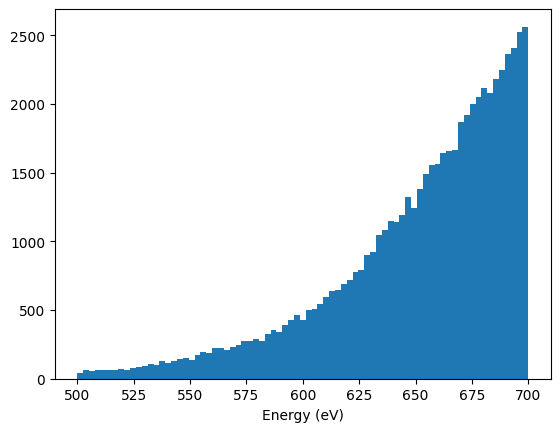

In [181]:
# extract data from table by referencing column name
# demo histogram for the energy of each photon
# gives a sense for the spectrum

energy_hist = plt.hist(evt_data['energy'], bins='auto')
plt.xlabel('Energy (eV)')

### Making 2D Histo w/ some table data

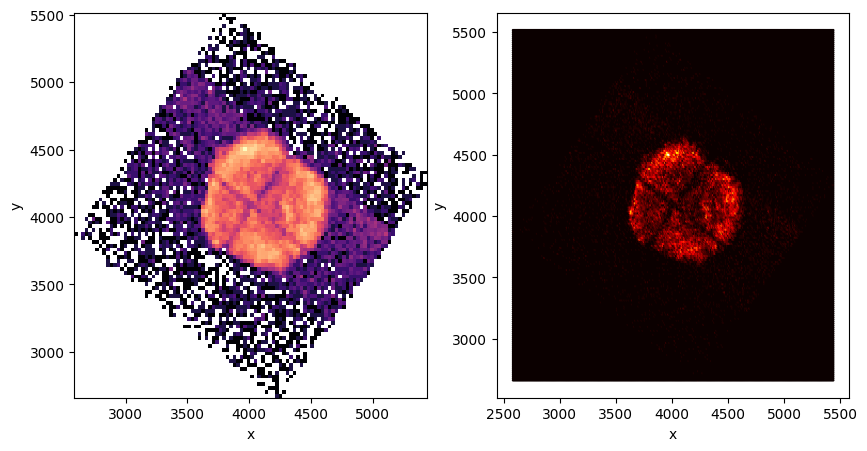

In [194]:
# we make image by binning x and y coords of the events into 2D histo

ii = np.in1d(evt_data['ccd_id'], [0, 1, 2, 3])
np.sum(ii)

NBINS = (100,100)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
ax = axs[0]
img_zero_mpl = ax.hist2d(evt_data['x'][ii], evt_data['y'][ii], bins=NBINS, cmap='magma', norm=LogNorm())
ax.set_xlabel('x')
ax.set_ylabel('y')

ax = axs[1]
img_zero_mpl = ax.hexbin(evt_data['x'][ii], evt_data['y'][ii], gridsize=300, cmap='hot')
ax.set_xlabel('x')
ax.set_ylabel('y')

hdu_list.close()


In [170]:
#fig, axes = plt.subplots(12, 3, figsize=(12, 48))

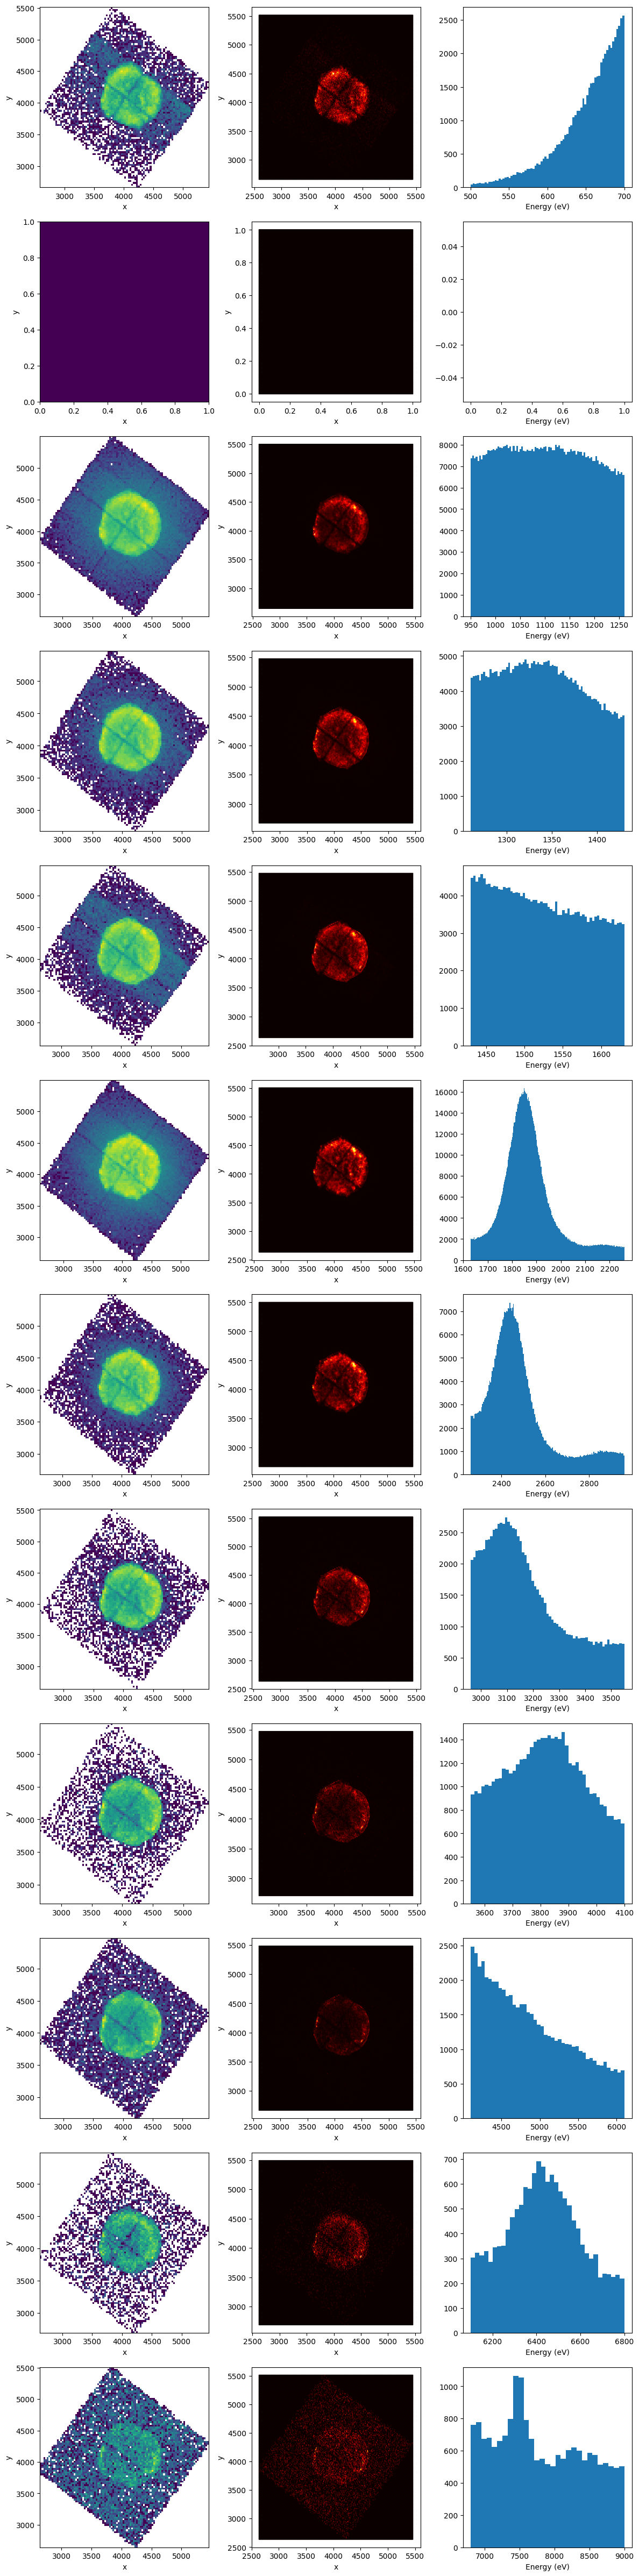

In [197]:
import numpy as np
from astropy.io import fits
from astropy.table import Table
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt

# Event filenames
event_filenames = ['/content/drive/MyDrive/TYCHO/bin1_3837.fits',
                   '/content/drive/MyDrive/TYCHO/bin2_3837.fits',
                   '/content/drive/MyDrive/TYCHO/bin3_3837.fits',
                   '/content/drive/MyDrive/TYCHO/bin4_3837.fits',
                   '/content/drive/MyDrive/TYCHO/bin5_3837.fits',
                   '/content/drive/MyDrive/TYCHO/bin6_3837.fits',
                   '/content/drive/MyDrive/TYCHO/bin7_3837.fits',
                   '/content/drive/MyDrive/TYCHO/bin8_3837.fits',
                   '/content/drive/MyDrive/TYCHO/bin9_3837.fits',
                   '/content/drive/MyDrive/TYCHO/bin10_3837.fits',
                   '/content/drive/MyDrive/TYCHO/bin11_3837.fits',
                   '/content/drive/MyDrive/TYCHO/bin12_3837.fits']

# Create figure and axes
fig, axes = plt.subplots(12, 3, figsize=(12, 48))

# Loop through event filenames
for i, filename in enumerate(event_filenames):
    # Open the FITS file
    hdu_list = fits.open(filename, memap=True)
    evt_data = Table(hdu_list[1].data)

    # Filter data
    ii = np.in1d(evt_data['ccd_id'], [0, 1, 2, 3])

    # Plot 2D histogram with hist2d
    ax = axes[i, 0]
    ax.hist2d(evt_data['x'][ii], evt_data['y'][ii], bins=(100, 100), cmap='viridis', norm=LogNorm())
    ax.set_xlabel('x')
    ax.set_ylabel('y')

    # Plot 2D histogram with hexbin
    ax = axes[i, 1]
    ax.hexbin(evt_data['x'][ii], evt_data['y'][ii], gridsize=300, cmap='hot')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

    # Plot energy histogram
    ax = axes[i, 2]
    ax.hist(evt_data['energy'], bins='auto')
    ax.set_xlabel('Energy (eV)')

    # Close the FITS file
    hdu_list.close()

plt.tight_layout() # Adjust spacing between subplots
plt.show()